In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 1000)

df = pd.read_csv("data\\games_data.csv")
df = df.drop(columns=["img"])

numeric = df.select_dtypes(include=["number"]).columns
df[numeric] = df[numeric].fillna(0)

print(df)

                                  title console         genre             publisher             developer  critic_score  total_sales  na_sales  jp_sales  pal_sales  other_sales release_date last_update
0                    Grand Theft Auto V     PS3        Action        Rockstar Games        Rockstar North           9.4        20.32      6.37      0.99       9.85         3.12   2013-09-17         NaN
1                    Grand Theft Auto V     PS4        Action        Rockstar Games        Rockstar North           9.7        19.39      6.06      0.60       9.71         3.02   2014-11-18  2018-01-03
2           Grand Theft Auto: Vice City     PS2        Action        Rockstar Games        Rockstar North           9.6        16.15      8.41      0.47       5.49         1.78   2002-10-28         NaN
3                    Grand Theft Auto V    X360        Action        Rockstar Games        Rockstar North           0.0        15.86      9.06      0.06       5.33         1.42   2013-09-17   

- Add most popular consoles and genres

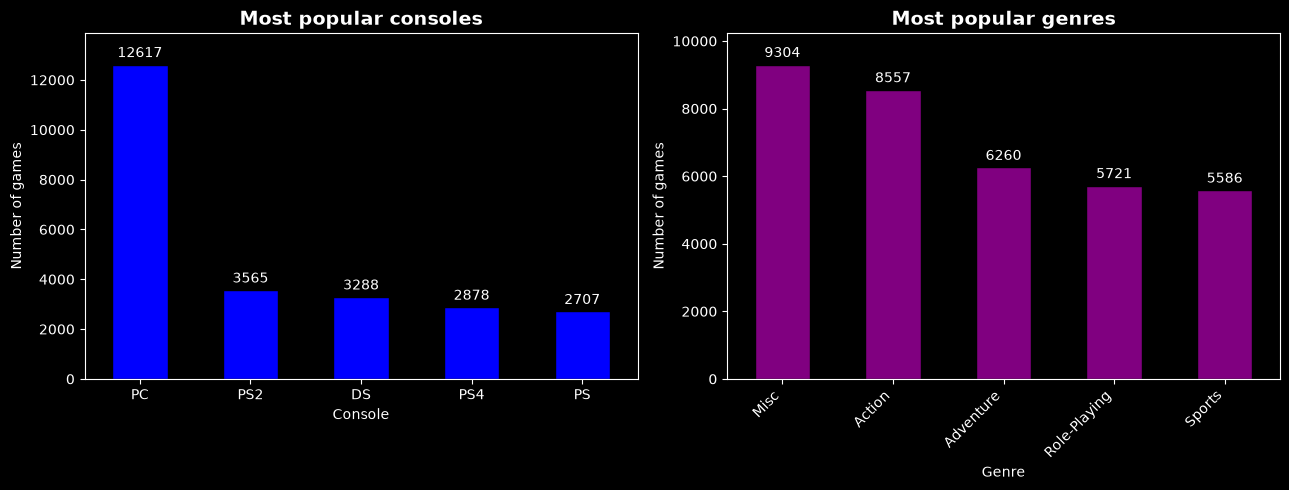

In [30]:
cg = df[["console", "genre"]]

console_counts = df["console"].value_counts().head(5)
genre_counts = df["genre"].value_counts().head(5)

#########

# 2 WSPÓLNE WYKRESY

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

console_counts.plot(
    kind="bar", 
    color='blue', 
    edgecolor='black',
    ax=ax1
)
ax1.bar_label(ax1.containers[0], padding=3)
ax1.set_title("Most popular consoles", fontsize=14, fontweight='bold')
ax1.set_xlabel("Console")
ax1.set_ylabel("Number of games")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.set_ylim(0, console_counts.max() * 1.1)

genre_counts.plot(
    kind="bar", 
    color='purple', 
    edgecolor='black',
    ax=ax2
)
ax2.bar_label(ax2.containers[0], padding=3)
ax2.set_title("Most popular genres", fontsize=14, fontweight='bold')
ax2.set_xlabel("Genre")
ax2.set_ylabel("Number of games")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_ylim(0, genre_counts.max() * 1.1)

plt.style.use("dark_background")
plt.tight_layout()
plt.show()



Identifying bestsellers— genres achieving the highest global sales

In [31]:
sales_cols = [col for col in df.columns if col.endswith("_sales")]

bestsellers = (
    df.groupby("title", as_index=False)[sales_cols]
      .sum()
      .sort_values("total_sales", ascending=False)
      .set_index("title")
)

print(bestsellers.head(10))

                                total_sales  na_sales  jp_sales  pal_sales  other_sales
title                                                                                  
Grand Theft Auto V                    64.29     26.19      1.66      28.14         8.32
Call of Duty: Black Ops               30.99     17.65      0.59       9.45         3.31
Call of Duty: Modern Warfare 3        30.71     15.57      0.62      11.26         3.26
Call of Duty: Black Ops II            29.59     14.12      0.72      11.08         3.67
Call of Duty: Ghosts                  28.80     15.06      0.49       9.60         3.65
Call of Duty: Black Ops 3             26.72     12.82      0.50       9.76         3.63
Call of Duty: Modern Warfare 2        25.02     13.54      0.46       8.08         2.95
Minecraft                             24.01      9.07      2.50       9.48         2.96
Grand Theft Auto IV                   22.53     11.60      0.58       7.64         2.72
Call of Duty: Advanced Warfare  